<a href="https://colab.research.google.com/github/gandhias-a11y/colab/blob/main/lab10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ch 5 Binary Classification

In [ ]:
import pandas as pd
attrition_past=pd.read_csv('https://bradfordtuckfield.com/attrition_past.csv')
print(attrition_past.head())
pd.set_option('display.max_columns', 6)

  corporation  lastmonth_activity  lastyear_activity  number_of_employees  \
0        abcd                  78               1024                   12   
1        asdf                  14               2145                   20   
2        xyzz                 182               3891                   35   
3        acme                 101              10983                    2   
4        qwer                   0                118                   42   

   exited  
0       1  
1       0  
2       0  
3       1  
4       1  


In [ ]:
print(attrition_past['exited'].mean())

0.5769230769230769


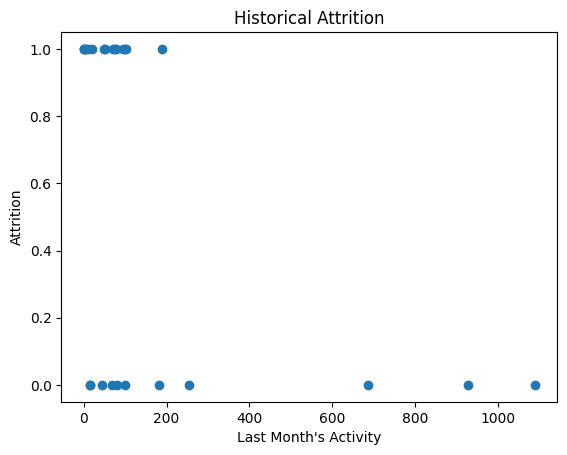

In [ ]:
from matplotlib import pyplot as plt
plt.scatter(attrition_past['lastmonth_activity'],attrition_past['exited'])
plt.title('Historical Attrition')
plt.xlabel('Last Month\'s Activity')
plt.ylabel('Attrition')
plt.show()

In [ ]:
x = attrition_past['lastmonth_activity'].values.reshape(-1,1)
y = attrition_past['exited'].values.reshape(-1,1)
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(x, y)

LinearRegression()

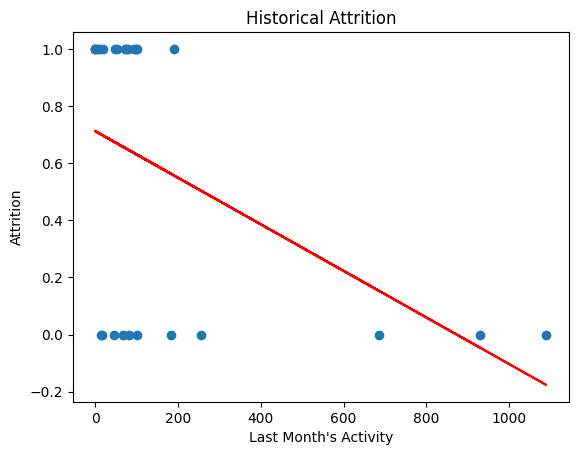

In [ ]:
from matplotlib import pyplot as plt
plt.scatter(attrition_past['lastmonth_activity'],attrition_past['exited'])
prediction = [regressor.coef_[0]*x+regressor.intercept_[0] for x in \
list(attrition_past['lastmonth_activity'])]
plt.plot(attrition_past['lastmonth_activity'], prediction, color='red')
plt.title('Historical Attrition')
plt.xlabel('Last Month\'s Activity')
plt.ylabel('Attrition')
plt.show()

In [ ]:
attrition_past['predicted']=regressor.predict(x)
attrition_past.head()

,corporation,lastmonth_activity,lastyear_activity,number_of_employees,exited,predicted
0,abcd,78,1024,12,1,0.648363
1,asdf,14,2145,20,0,0.700525
2,xyzz,182,3891,35,0,0.563600
3,acme,101,10983,2,1,0.629618
4,qwer,0,118,42,1,0.711936


In [ ]:
attrition_future=pd.read_csv('http://bradfordtuckfield.com/attrition2.csv')
print(attrition_future.head())

  corporation  lastmonth_activity  lastyear_activity  number_of_employees
0        hhtn                 166               1393                   91
1        slfm                 824              16920                  288
2        pryr                  68                549                   12
3        ahva                 121               1491                   16
4        dmai                   4                 94                    2


In [ ]:
x = attrition_future['lastmonth_activity'].values.reshape(-1,1)
attrition_future['predicted']=regressor.predict(x)
print(attrition_future.head())

  corporation  lastmonth_activity  lastyear_activity  number_of_employees  \
0        hhtn                 166               1393                   91   
1        slfm                 824              16920                  288   
2        pryr                  68                549                   12   
3        ahva                 121               1491                   16   
4        dmai                   4                 94                    2   

   predicted  
0   0.576641  
1   0.040352  
2   0.656514  
3   0.613317  
4   0.708676  


In [ ]:
print(attrition_future.nlargest(5,'predicted'))

   corporation  lastmonth_activity  lastyear_activity  number_of_employees  \
8         whsh                   0                 40                   52   
12        mike                   0                  0                   49   
24        pian                   0                 12                   19   
21        bass                   2                 19                 1400   
4         dmai                   4                 94                    2   

    predicted  
8    0.711936  
12   0.711936  
24   0.711936  
21   0.710306  
4    0.708676  


In [ ]:
print(list(attrition_future.sort_values(by='predicted',ascending=False).loc[:,'corporation']))

['whsh', 'mike', 'pian', 'bass', 'pevc', 'dmai', 'ynus', 'hlpd', 'kdic', 'angl', 'erin', 'oscr', 'grce', 'zamk', 'hlly', 'xkcd', 'dwgt', 'pryr', 'skct', 'frgv', 'ejdc', 'ahva', 'wlcj', 'hhtn', 'slfm', 'cred']


In [ ]:
print(list(attrition_future.loc[attrition_future['predicted']>0.7,'corporation']))

['dmai', 'whsh', 'oscr', 'kdic', 'mike', 'pevc', 'erin', 'angl', 'bass', 'ynus', 'pian', 'hlpd']


In [ ]:
themedian=attrition_past['predicted'].median()
prediction=list(1*(attrition_past['predicted']>themedian))
actual=list(attrition_past['exited'])

In [ ]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(prediction,actual))

[[7 6]
 [4 9]]


In [ ]:
conf_mat = confusion_matrix(prediction,actual)
precision = conf_mat[0][0]/(conf_mat[0][0]+conf_mat[0][1])
recall = conf_mat[0][0]/(conf_mat[0][0]+conf_mat[1][0])
print(precision)
print(recall)

0.5384615384615384
0.6363636363636364


In [ ]:
x3 = attrition_past.loc[:,['lastmonth_activity', 'lastyear_activity',\
 'number_of_employees']].values.reshape(-1,3)
y = attrition_past['exited'].values.reshape(-1,1)
regressor_multi = LinearRegression()
regressor_multi.fit(x3, y)

LinearRegression()

In [ ]:
attrition_future['predicted_multi']=regressor_multi.predict(x3)
print(attrition_future.nlargest(5,'predicted_multi'))

   corporation  lastmonth_activity  lastyear_activity  number_of_employees  \
11        ejdc                  95               1005                   61   
12        mike                   0                  0                   49   
13        pevc                   4                  6                 1686   
4         dmai                   4                 94                    2   
22        ynus                   9                 90                   12   

    predicted  predicted_multi  
11   0.634508         0.870000  
12   0.711936         0.815677  
13   0.708676         0.788110  
4    0.708676         0.755625  
22   0.704600         0.715362  


In [ ]:
print(list(attrition_future.sort_values(by='predicted_multi',\
ascending=False).loc[:,'corporation']))

['ejdc', 'mike', 'pevc', 'dmai', 'ynus', 'wlcj', 'angl', 'pian', 'slfm', 'hlpd', 'frgv', 'hlly', 'oscr', 'cred', 'dwgt', 'hhtn', 'whsh', 'grce', 'pryr', 'xkcd', 'bass', 'ahva', 'erin', 'zamk', 'skct', 'kdic']


In [ ]:
attrition_future['activity_per_employee']=attrition_future.loc[:,\
'lastmonth_activity']/attrition_future.loc[:,'number_of_employees']

In [ ]:
attrition_past['activity_per_employee']=attrition_past.loc[:,\
'lastmonth_activity']/attrition_past.loc[:,'number_of_employees']
x = attrition_past.loc[:,['activity_per_employee','lastmonth_activity',\
 'lastyear_activity', 'number_of_employees']].values.reshape(-1,4)
y = attrition_past['exited'].values.reshape(-1,1)
regressor_derived= LinearRegression()
regressor_derived.fit(x, y)
attrition_past['predicted3']=regressor_derived.predict(x)
x = attrition_future.loc[:,['activity_per_employee','lastmonth_activity',\
 'lastyear_activity', 'number_of_employees']].values.reshape(-1,4)
attrition_future['predicted3']=regressor_derived.predict(x)

print(list(attrition_future.sort_values(by='predicted3',ascending=False).loc[:,'corporation']))

['pevc', 'bass', 'frgv', 'hlpd', 'angl', 'oscr', 'zamk', 'whsh', 'mike', 'hhtn', 'ejdc', 'grce', 'pian', 'ynus', 'dmai', 'kdic', 'erin', 'slfm', 'dwgt', 'pryr', 'hlly', 'xkcd', 'skct', 'ahva', 'wlcj', 'cred']


In [ ]:
themedian=attrition_past['predicted3'].median()
prediction=list(1*(attrition_past['predicted3']>themedian))
actual=list(attrition_past['exited'])
print(confusion_matrix(prediction,actual))

[[ 9  4]
 [ 2 11]]


In [ ]:
conf_mat = confusion_matrix(prediction,actual)
precision = conf_mat[0][0]/(conf_mat[0][0]+conf_mat[0][1])
recall = conf_mat[0][0]/(conf_mat[0][0]+conf_mat[1][0])
print(precision)
print(recall)

0.6923076923076923
0.8181818181818182


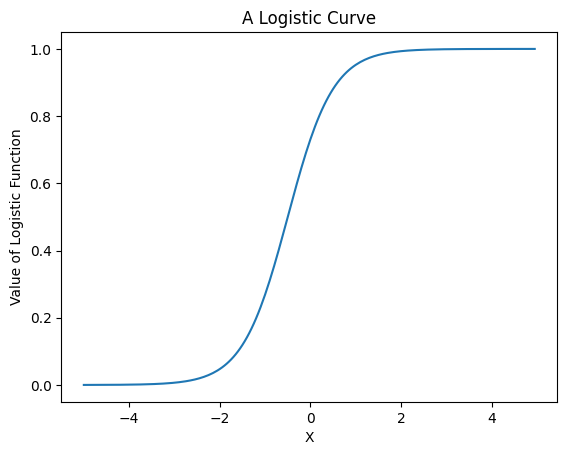

In [ ]:
from matplotlib import pyplot as plt
import numpy as np
import math
x = np.arange(-5, 5, 0.05)
y = (1/(1+np.exp(-1-2*x)))
plt.plot(x,y)
plt.xlabel("X")
plt.ylabel("Value of Logistic Function")
plt.title('A Logistic Curve')
plt.show()

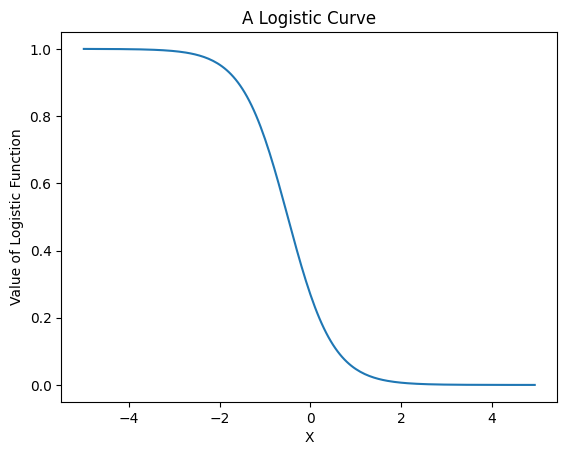

In [ ]:
x = np.arange(-5, 5, 0.05)
y = (1/(1+np.exp(1+2*x)))
plt.plot(x,y)
plt.xlabel("X")
plt.ylabel("Value of Logistic Function")
plt.title('A Logistic Curve')
plt.show()

In [ ]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(solver='liblinear', random_state=0)
x = attrition_past['lastmonth_activity'].values.reshape(-1,1)
y = attrition_past['exited']
model.fit(x, y)

LogisticRegression(random_state=0, solver='liblinear')

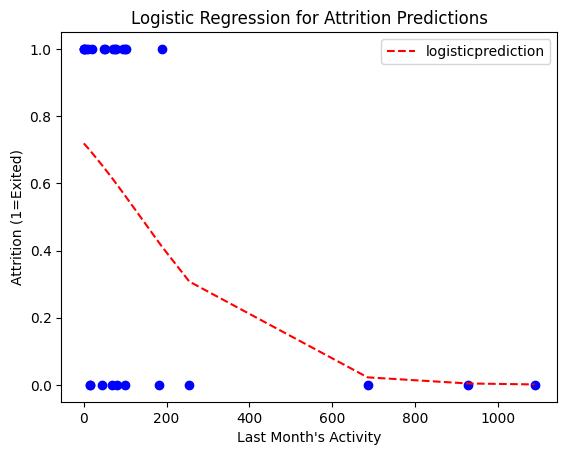

In [ ]:
attrition_past['logisticprediction']=model.predict_proba(x)[:,1]

fig = plt.scatter(attrition_past['lastmonth_activity'],attrition_past['exited'], color='blue')
attrition_past.sort_values('lastmonth_activity').plot('lastmonth_activity',\
'logisticprediction',ls='--', ax=fig.axes,color='red')
plt.title('Logistic Regression for Attrition Predictions')
plt.xlabel('Last Month\'s Activity')
plt.ylabel('Attrition (1=Exited)')
plt.show()

In [ ]:
x = attrition_future['lastmonth_activity'].values.reshape(-1,1)
attrition_future['logisticprediction']=model.predict_proba(x)[:,1]
print(list(attrition_future.sort_values(by='logisticprediction',\
ascending=False).loc[:,'corporation']))

['whsh', 'mike', 'pian', 'bass', 'pevc', 'dmai', 'ynus', 'hlpd', 'kdic', 'angl', 'erin', 'oscr', 'grce', 'zamk', 'hlly', 'xkcd', 'dwgt', 'pryr', 'skct', 'frgv', 'ejdc', 'ahva', 'wlcj', 'hhtn', 'slfm', 'cred']


Ch 5 Overview:

The chapter sets out to use binary classification (the decision making process behind sorting datapoints into one of two categories) to see whether the clients of our fictional company have a high or low risk for attrition.

We start off by examining our dataset. We focus on the attrition rate for the client list (~58%). After creating a scatter plot, we can see that, generally, clients who have activity less than 400 are the only ones who leave our services. We double check this hypothesis by creating a linear regression which shows the negative association between attrition and activity. However, a linear regression is not a good predictor for this type of data because it implies there are outcomes other than exiting or not exiting (0 or 1). Binary classification uses something called a linear probability model. Thus, we interpret the numbers in between 0 and 1 as the probability that the client will exit our services.

Now, the chapter encourages the use of our new predictions. We download a new dataset of more "recent" data and create a new column within it using our regressor from before. We now have a probability of attrition for each of the clients in our new dataset.

Next, we need to turn our new predictions into something tangible for our company. First, we search for the 5 clients most liikely to leave us. Then, we rank our clients by attrition probability. Finally, we list all of the clients with an attrition probability greater than 70%. All three of these tactics provide useful information for our company's efforts to retain our clients.

Now, the book wants us to analyze how accurate our prediction is. We first make lists of our predicted probabilities and the actual attritions from our first dataset. We turn this into something called a confusion matrix which tells us the number of true positives, false positives, false negatives, and true negatives. Our prediction model yielded 10 incorrect predictions and 16 correct ones. We then calculate two statistics known as precision and recall. Precision determines the proportion of true positives out of all positive predictions while recall determines the proportion of true positives out of all actual positives. Ideally, these numbers are as close to 1 as possible.

The text warns us that regressions are more useful when we are looking at relationships that aren't immediately obvious or do not have a clear association. So, the book proposes a multi-variate regression to look at the impacts of multiple variables on the outcome variable. This regression is also a linear probability model. The output of the multi-variate regression is a lot more confusing to interpret, so we rank and print the top clients for attrition risk.

We next look at creating a derived feature out of our regression. A derived feature is "a feature or metric created by transforming and combining existing variables" (106). For our example, we make a variable that divides activty by the number of employees per client. The hope is that this new metric is a better predictor of attrition. To check this, we make a confusion matrix that has a higher correct to incorrect ratio than our first regression did.

However, the text warns us that linear probability models have many weaknesses such as including negative probabilities in its outcomes. To avoid this issue, we can use logistic regression models to predict our attrition probability because they only include values between 0 and 1. We first reshape our data into only 1 column with reshape(-1,1), and then fit our activity and exit variables into the log model. Next, we print the model with the predictor added on and print the ranked clients in order of attrition probability.

The chapter ends with some warning about the use of linear probability models and logistic regressions. These models cannot tell us the why behind the trends and they can only express trends that move in only one direction, nothing more complex than that.